# Anomaly detection on the NASA Shuttle dataset with Isolation Forest

Class 1 is the normal state (about 80% of the data); classes 2 to 7 are treated as anomalies.

Steps:
1. Load the data, drop the time column and the duplicate rows
2. Split into train / validation / test (60/20/20, stratified)
3. Tune Isolation Forest on the validation set
4. Choose the decision threshold
5. Evaluate once on the test set

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Loading and cleaning the data

A1 is the time attribute so we remove it. We also remove duplicate rows before splitting, otherwise the same row could end up in both the train and the test set.

Dropped column: A1
Duplicate rows: 2059
Shape: (55941, 9)
class
1    43981
2       49
3      171
4     8488
5     3229
6       10
7       13
Name: count, dtype: int64
Anomaly percentage: 21.38%


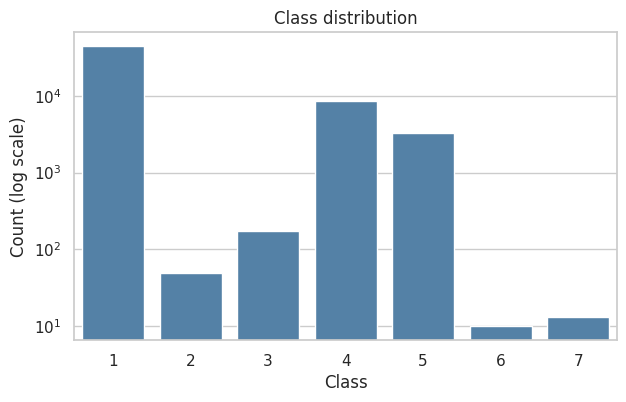

In [8]:
shuttle = fetch_openml("shuttle", version=1, as_frame=True)
df = shuttle.data.copy()
df["class"] = shuttle.target.astype(str)

# drop the time column
time_col = "A1" if "A1" in df.columns else df.columns[0]
df = df.drop(columns=time_col)
print("Dropped column:", time_col)

# remove duplicates
features = [c for c in df.columns if c != "class"]
dup = df.duplicated(subset=features)
print("Duplicate rows:", dup.sum())
df = df[~dup].reset_index(drop=True)

print("Shape:", df.shape)
counts = df["class"].value_counts().sort_index()
print(counts)
print(f"Anomaly percentage: {100 * (df['class'] != '1').mean():.2f}%")

plt.figure(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.values, color="steelblue")
plt.yscale("log")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.title("Class distribution")
plt.show()

## 2. Train / validation / test split

We stratify on the original class so the rare classes (6 and 7) appear in each split. The test set is only used at the very end.

In [9]:
X = df[features]
cls = df["class"]

X_tmp, X_test, c_tmp, c_test = train_test_split(X, cls, test_size=0.20, stratify=cls, random_state=SEED)
X_train, X_val, c_train, c_val = train_test_split(X_tmp, c_tmp, test_size=0.25, stratify=c_tmp, random_state=SEED)

# constant features (checked on the training set)
constant = [c for c in features if X_train[c].nunique() <= 1]
if constant:
    print("Dropping constant features:", constant)
    X_train, X_val, X_test = (d.drop(columns=constant) for d in (X_train, X_val, X_test))
else:
    print("No constant features")

# labels: 1 = anomaly, 0 = normal
y_train, y_val, y_test = ((c != "1").astype(int).to_numpy() for c in (c_train, c_val, c_test))

print(pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "anomalies": [y_train.sum(), y_val.sum(), y_test.sum()],
    "anomaly %": [100 * y_train.mean(), 100 * y_val.mean(), 100 * y_test.mean()],
}, index=["train", "validation", "test"]))

No constant features
             rows  anomalies  anomaly %
train       33564       7176    21.3801
validation  11188       2392    21.3801
test        11189       2392    21.3781


Note: we don't scale the features. Isolation Forest picks split values between the min and max of each feature, so scaling doesn't change the result.

## 3. Baseline

Since most of the data is normal, a model that always predicts "normal" already gets a high accuracy. We use it as a reference.

In [10]:
majority = np.zeros_like(y_test)
baseline_row = {
    "model": "Baseline (always normal)", "threshold": "-",
    "PR-AUC": y_test.mean(), "ROC-AUC": 0.5,
    "precision": 0.0, "recall": 0.0, "F1 (anomaly)": 0.0,
    "accuracy": accuracy_score(y_test, majority),
}
print("Baseline accuracy:", round(baseline_row["accuracy"], 4))

Baseline accuracy: 0.7862


## 4. Hyperparameter tuning

The configurations are compared on the validation set using the average precision (PR-AUC) of the anomaly class, which does not depend on a threshold.

We try two ways of training the model:
- **A: unsupervised**, trained on all the training rows (labels are not used)
- **B: trained on normal data only**, i.e. only the class 1 rows of the training set

In [11]:
param_grid = ParameterGrid({
    "n_estimators": [100, 300],
    "max_samples": [256, 0.25, 1.0],
    "max_features": [0.5, 1.0],
})

def anomaly_score(model, X):
    # score_samples is higher for normal points, so we take the opposite
    return -model.score_samples(X)

settings = {
    "A (unsupervised)": X_train,
    "B (normal only)": X_train[y_train == 0],
}

rows, best = [], {}
for setting, X_fit in settings.items():
    for params in param_grid:
        model = IsolationForest(random_state=SEED, n_jobs=-1, **params).fit(X_fit)
        ap = average_precision_score(y_val, anomaly_score(model, X_val))
        rows.append({"setting": setting, **params, "val PR-AUC": ap})
        if setting not in best or ap > best[setting][0]:
            best[setting] = (ap, params, model)

search = pd.DataFrame(rows).sort_values(["setting", "val PR-AUC"], ascending=[True, False])
display(search.groupby("setting").head(5).reset_index(drop=True))

for setting, (ap, params, _) in best.items():
    print(setting, "best params:", params, "val PR-AUC:", round(ap, 4))

,setting,max_features,max_samples,n_estimators,val PR-AUC
0,A (unsupervised),0.5000,256.0000,300,0.6659
1,A (unsupervised),1.0000,256.0000,100,0.6647
2,A (unsupervised),1.0000,256.0000,300,0.6566
3,A (unsupervised),0.5000,256.0000,100,0.6393
4,A (unsupervised),1.0000,0.2500,100,0.6280
5,B (normal only),1.0000,1.0000,300,0.8597
6,B (normal only),0.5000,0.2500,100,0.8510
7,B (normal only),0.5000,1.0000,100,0.8470
8,B (normal only),1.0000,0.2500,300,0.8459
9,B (normal only),1.0000,1.0000,100,0.8439


A (unsupervised) best params: {'max_features': 0.5, 'max_samples': 256, 'n_estimators': 300} val PR-AUC: 0.6659
B (normal only) best params: {'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 300} val PR-AUC: 0.8597


## 5. Decision threshold

We compare two thresholds:
- the default one from `contamination="auto"`, which doesn't need any labels
- the threshold that gives the best anomaly F1 on the validation set

In [12]:
def best_f1_threshold(y, s):
    p, r, t = precision_recall_curve(y, s)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    i = int(np.nanargmax(f1[:-1]))
    return float(t[i]), float(f1[i])

thresholds = {}
for setting, (_, _, model) in best.items():
    s_val = anomaly_score(model, X_val)
    t_auto = -model.offset_
    t_val, f1_val = best_f1_threshold(y_val, s_val)
    thresholds[setting] = {"auto": t_auto, "tuned on validation": t_val}
    print(f"{setting}: auto = {t_auto:.4f}, tuned = {t_val:.4f} (val F1 = {f1_val:.4f})")

A (unsupervised): auto = 0.5000, tuned = 0.4411 (val F1 = 0.5689)
B (normal only): auto = 0.5000, tuned = 0.4464 (val F1 = 0.7640)


## 6. Results on the test set

In [13]:
def evaluate(name, thr_name, y, s, thr):
    pred = (s >= thr).astype(int)
    return {"model": name, "threshold": thr_name,
            "PR-AUC": average_precision_score(y, s), "ROC-AUC": roc_auc_score(y, s),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "F1 (anomaly)": f1_score(y, pred, zero_division=0),
            "accuracy": accuracy_score(y, pred)}

test_scores, results = {}, [baseline_row]
for setting, (_, params, model) in best.items():
    s = anomaly_score(model, X_test)
    test_scores[setting] = s
    for thr_name, thr in thresholds[setting].items():
        results.append(evaluate(setting, thr_name, y_test, s, thr))

report = pd.DataFrame(results)
display(report)

,model,threshold,PR-AUC,ROC-AUC,precision,recall,F1 (anomaly),accuracy
0,Baseline (always normal),-,0.2138,0.5000,0.0000,0.0000,0.0000,0.7862
1,A (unsupervised),auto,0.6734,0.8464,0.7211,0.4411,0.5473,0.8440
2,A (unsupervised),tuned on validation,0.6734,0.8464,0.4777,0.7262,0.5763,0.7717
3,B (normal only),auto,0.8700,0.9510,0.9884,0.4967,0.6611,0.8911
4,B (normal only),tuned on validation,0.8700,0.9510,0.9314,0.6639,0.7752,0.9177


Detection rate for each class on the test set (for class 1 this is the false positive rate):

In [14]:
per_class = {}
for setting, s in test_scores.items():
    flagged = s >= thresholds[setting]["tuned on validation"]
    per_class[setting] = pd.Series(flagged).groupby(c_test.to_numpy()).mean()
per_class = pd.DataFrame(per_class)
per_class.insert(0, "test rows", c_test.value_counts().sort_index())
per_class.index.name = "class"
display(per_class)

,test rows,A (unsupervised),B (normal only)
class,,,
1,8797,0.2159,0.0133
2,10,0.9000,0.7000
3,34,1.0000,0.7647
4,1698,0.6148,0.5330
5,646,1.0000,1.0000
6,2,1.0000,1.0000
7,2,1.0000,1.0000


## 7. Plots

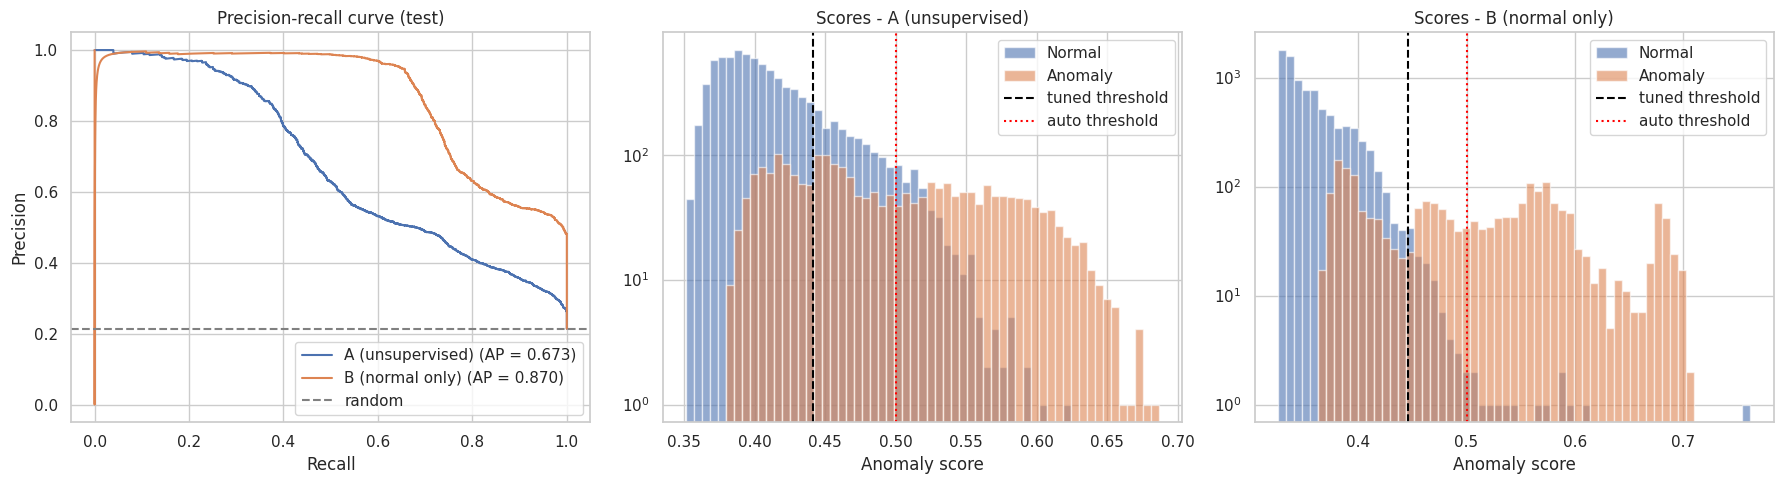

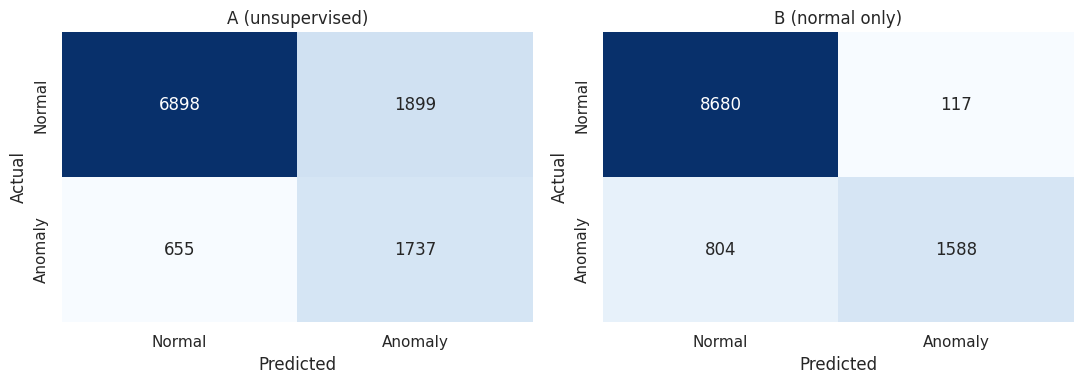

A (unsupervised)
              precision    recall  f1-score   support

      Normal     0.9133    0.7841    0.8438      8797
     Anomaly     0.4777    0.7262    0.5763      2392

    accuracy                         0.7717     11189
   macro avg     0.6955    0.7552    0.7101     11189
weighted avg     0.8202    0.7717    0.7866     11189

B (normal only)
              precision    recall  f1-score   support

      Normal     0.9152    0.9867    0.9496      8797
     Anomaly     0.9314    0.6639    0.7752      2392

    accuracy                         0.9177     11189
   macro avg     0.9233    0.8253    0.8624     11189
weighted avg     0.9187    0.9177    0.9123     11189



In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# precision-recall curves
for setting, s in test_scores.items():
    p, r, _ = precision_recall_curve(y_test, s)
    axes[0].plot(r, p, label=f"{setting} (AP = {average_precision_score(y_test, s):.3f})")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="random")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-recall curve (test)")
axes[0].legend()

# score histograms
for ax, (setting, s) in zip(axes[1:], test_scores.items()):
    bins = np.linspace(s.min(), s.max(), 60)
    ax.hist(s[y_test == 0], bins=bins, alpha=0.6, label="Normal")
    ax.hist(s[y_test == 1], bins=bins, alpha=0.6, label="Anomaly")
    ax.axvline(thresholds[setting]["tuned on validation"], color="black", linestyle="--", label="tuned threshold")
    ax.axvline(thresholds[setting]["auto"], color="red", linestyle=":", label="auto threshold")
    ax.set_yscale("log")
    ax.set_xlabel("Anomaly score")
    ax.set_title(f"Scores - {setting}")
    ax.legend()
plt.tight_layout()
plt.show()

# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (setting, s) in zip(axes, test_scores.items()):
    pred = (s >= thresholds[setting]["tuned on validation"]).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(setting)
plt.tight_layout()
plt.show()

for setting, s in test_scores.items():
    pred = (s >= thresholds[setting]["tuned on validation"]).astype(int)
    print(setting)
    print(classification_report(y_test, pred, target_names=["Normal", "Anomaly"], digits=4))

## 8. Effect of the random seed

We train the best configurations again with 5 different seeds to see how much the results vary.

In [16]:
stab = []
for setting, (_, params, _) in best.items():
    X_fit = settings[setting]
    for seed in range(5):
        m = IsolationForest(random_state=seed, n_jobs=-1, **params).fit(X_fit)
        s_val, s_te = anomaly_score(m, X_val), anomaly_score(m, X_test)
        thr, _ = best_f1_threshold(y_val, s_val)
        stab.append({"setting": setting, "seed": seed,
                     "test PR-AUC": average_precision_score(y_test, s_te),
                     "test F1 (anomaly)": f1_score(y_test, (s_te >= thr).astype(int))})
stab = pd.DataFrame(stab)
display(stab.groupby("setting")[["test PR-AUC", "test F1 (anomaly)"]].agg(["mean", "std"]))

test PR-AUC        test F1 (anomaly)       
                        mean    std              mean    std
setting                                                     
A (unsupervised)      0.6488 0.0168            0.5548 0.0042
B (normal only)       0.8598 0.0067            0.7672 0.0066

## 9. Summary

In [17]:
print(report.to_string(index=False))

best_row = report.iloc[1:].sort_values("F1 (anomaly)", ascending=False).iloc[0]
print()
print("Best model:", best_row["model"], "with the", best_row["threshold"], "threshold")
print(f"F1 (anomaly) = {best_row['F1 (anomaly)']:.3f}, PR-AUC = {best_row['PR-AUC']:.3f}, "
      f"accuracy = {best_row['accuracy']:.3f} (baseline: {baseline_row['accuracy']:.3f})")

                   model           threshold  PR-AUC  ROC-AUC  precision  recall  F1 (anomaly)  accuracy
Baseline (always normal)                   -  0.2138   0.5000     0.0000  0.0000        0.0000    0.7862
        A (unsupervised)                auto  0.6734   0.8464     0.7211  0.4411        0.5473    0.8440
        A (unsupervised) tuned on validation  0.6734   0.8464     0.4777  0.7262        0.5763    0.7717
         B (normal only)                auto  0.8700   0.9510     0.9884  0.4967        0.6611    0.8911
         B (normal only) tuned on validation  0.8700   0.9510     0.9314  0.6639        0.7752    0.9177

Best model: B (normal only) with the tuned on validation threshold
F1 (anomaly) = 0.775, PR-AUC = 0.870, accuracy = 0.918 (baseline: 0.786)


### Conclusion

- Accuracy is not a good metric here because of the class imbalance, so we focus on PR-AUC and the F1 score of the anomaly class.
- Model A is fully unsupervised. Model B needs normal data for training, which is realistic for this kind of telemetry (normal operation data is easy to get), but it makes the approach semi-supervised.
- The "auto" threshold can be used without any labels, while the tuned threshold needs a small labelled validation set.